# Pipeline DEF-rgbtcc (Small Images) - Notebook 02: Inferência Neural e Contagem de Poucas Pessoas

Este notebook realiza a inferência neural da arquitetura **`DualStreamRGBTNet (VGG-19 + Modulação Espacial)`** no recorte padronizado gerado no Estágio 1, aplicando uma **estratégia dupla de contagem especializada para cenários de poucas pessoas** (Integral Contínua vs Detecção por Picos Locais).

> **Diretriz Didática:** Cada etapa contém uma explicação simples e direta sobre a escolha da lógica do código, seu fundamento técnico e o efeito prático esperado no resultado final.

## 1. Setup do Ambiente e Detecção Adaptativa de Hardware

**O que este código faz:**
Importa as bibliotecas necessárias, detecta automaticamente se uma GPU com suporte a CUDA está disponível e define os diretórios do contrato de dados (`output/01_pre_transformacao/`) e de entrega (`output/02_contagem/`).

**Por que esta lógica foi escolhida?**
A seleção adaptativa de hardware permite que o mesmo código execute com aceleração de GPU ou em modo multi-threaded de CPU sem exigir alterações manuais no script, garantindo portabilidade em qualquer estação de trabalho.

**Efeito prático no resultado:**
O dispositivo de computação (`cuda` ou `cpu`) é identificado e exibido no console.

In [11]:
import os
import sys
import time
import json
from pathlib import Path

# Configurar diretório de cache do Matplotlib
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"

import cv2
import torch
import numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT_DIR = NOTEBOOK_DIR.parent.parent
STAGE1_DIR = NOTEBOOK_DIR / "output" / "01_pre_transformacao"
OUTPUT_DIR = NOTEBOOK_DIR / "output" / "02_contagem"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Seleção automática de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODELO_NOME = "DEF-rgbtcc-small-images"
ARQUITETURA_NOME = "DualStreamRGBTNet (VGG-19 + Modulação Espacial)"

print("=" * 65)
print(f"[*] Pipeline Ativo:         {MODELO_NOME}")
print(f"[*] Arquitetura Neural:     {ARQUITETURA_NOME}")
print(f"[*] Dispositivo Ativo:      {device}")
if device.type == "cuda":
    print(f"    ├─ Placa de Vídeo:      {torch.cuda.get_device_name(0)}")
    print(f"    └─ VRAM Total:          {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print("=" * 65)

[*] Pipeline Ativo:         DEF-rgbtcc-small-images
[*] Arquitetura Neural:     DualStreamRGBTNet (VGG-19 + Modulação Espacial)
[*] Dispositivo Ativo:      cuda
    ├─ Placa de Vídeo:      NVIDIA GeForce RTX 4090
    └─ VRAM Total:          25.25 GB


## 2. Ingestão e Validação do Contrato de Dados (Estágio 1)

**O que este código faz:**
Lê os arquivos gerados pelo Notebook 01 (`rgb_preprocessed.jpg`, `thermal_preprocessed.jpg` e `metadata_preprocessing.json`) e verifica se eles atendem aos requisitos de resolução e canais.

**Por que esta lógica foi escolhida?**
Garante que o pipeline não falhe silenciosamente caso o Notebook 01 não tenha sido executado previamente, alertando o operador com mensagens claras em vez de disparar erros crípticos no meio da rede neural.

**Efeito prático no resultado:**
As imagens são carregadas na memória e as dimensões padronizadas são confirmadas.

In [12]:
p_rgb = STAGE1_DIR / "rgb_preprocessed.jpg"
p_th = STAGE1_DIR / "thermal_preprocessed.jpg"
p_meta = STAGE1_DIR / "metadata_preprocessing.json"

assert p_rgb.exists(), f"Erro: Insumo RGB não encontrado em {p_rgb}. Execute o Notebook 01 primeiro!"
assert p_th.exists(), f"Erro: Insumo Térmico não encontrado em {p_th}. Execute o Notebook 01 primeiro!"

img_rgb = cv2.cvtColor(cv2.imread(str(p_rgb)), cv2.COLOR_BGR2RGB)
img_th = cv2.cvtColor(cv2.imread(str(p_th)), cv2.COLOR_BGR2RGB)

with open(p_meta, "r", encoding="utf-8") as f:
    meta = json.load(f)

h, w = img_rgb.shape[:2]
real_count = meta.get("pessoas_reais_ground_truth", 0)
gt_points = meta.get("pontos_ground_truth", [])

print("=" * 65)
print(f"[✓] Contrato do Estágio 1 Carregado com Sucesso!")
print(f"    ├─ Amostra Avaliada:        {meta.get('nome_amostra')}")
print(f"    ├─ Dimensões do Recorte:    {w}x{h} px")
print(f"    └─ Pessoas Reais Conhecidas: {real_count} pessoas (Ground Truth)")
print("=" * 65)

[✓] Contrato do Estágio 1 Carregado com Sucesso!
    ├─ Amostra Avaliada:        Calçada de Pedestres no Solo (Fiscais)
    ├─ Dimensões do Recorte:    352x320 px
    └─ Pessoas Reais Conhecidas: 9 pessoas (Ground Truth)


## 3. Carregamento da Arquitetura Neural (`DualStreamRGBTNet (VGG-19 + Modulação Espacial)`)

**O que este código faz:**
Instancia a rede neural profunda e carrega os pesos treinados no dispositivo selecionado (`device`), colocando o modelo em modo de avaliação (`eval()`).

**Por que esta lógica foi escolhida?**
O comando `model.eval()` é mandatório na fase de inferência: ele desativa o *Dropout* (que descartaria neurônios aleatoriamente) e congela as camadas de *Batch Normalization*, garantindo predições determinísticas, estáveis e reprodutíveis.

**Efeito prático no resultado:**
A rede neural fica residente na memória da GPU pronta para processamento imediato.

In [13]:
# Carregar modelo DEF-rgbtcc (DualStreamRGBTNet)
for k in list(sys.modules.keys()):
    if k == "models" or k.startswith("models."):
        del sys.modules[k]

sys.path.insert(0, str(NOTEBOOK_DIR))
from models.models import DualStreamRGBTNet

model = DualStreamRGBTNet()
weight_path = ROOT_DIR / "weights" / "best_model.pth"
if weight_path.exists():
    ckpt = torch.load(weight_path, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    print(f"[✓] Pesos Calibrados Carregados: {weight_path.name}")
else:
    print("[!] Aviso: Checkpoint não encontrado, operando com pesos base.")

model.to(device).eval()
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[✓] Arquitetura 'DualStreamRGBTNet' pronta: {num_params/1e6:.2f}M parâmetros treináveis.")

[✓] Pesos Calibrados Carregados: best_model.pth
[✓] Arquitetura 'DualStreamRGBTNet' pronta: 0.76M parâmetros treináveis.


## 4. Pré-processamento e Normalização Estatística ImageNet

**O que este código faz:**
Transforma as matrizes de imagem em tensores PyTorch `[1, 3, H, W]`, convertendo os valores de pixel para a escala $[0, 1]$ e aplicando a padronização estatística do ImageNet:
$$\text{Tensor} = \frac{\text{Pixel} - \mu}{\sigma}$$
onde $\mu = [0.485, 0.456, 0.406]$ e $\sigma = [0.229, 0.224, 0.225]$.

**Por que esta lógica foi escolhida?**
Os backbones convolucionais pré-treinados foram otimizados assumindo distribuições normais com média zero. Alimentá-los com matrizes não-normalizadas geraria respostas saturadas e ativações fora de escala.

**Efeito prático no resultado:**
Tensores no formato adequado são transferidos para a memória da GPU.

In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

tensor_rgb = transform(img_rgb).unsqueeze(0).to(device)
tensor_th = transform(img_th).unsqueeze(0).to(device)

print(f"[✓] Tensores Gerados com Sucesso:")
print(f"    ├─ Formato do Tensor RGB:     {tensor_rgb.shape} no {device}")
print(f"    └─ Formato do Tensor Térmico: {tensor_th.shape} no {device}")

[✓] Tensores Gerados com Sucesso:
    ├─ Formato do Tensor RGB:     torch.Size([1, 3, 320, 352]) no cuda
    └─ Formato do Tensor Térmico: torch.Size([1, 3, 320, 352]) no cuda


## 5. Inferência Neural e Extração do Mapa de Densidade 2D

**O que este código faz:**
Alimenta os tensores óptico e térmico na rede neural dentro de um bloco `torch.no_grad()`, cronometrando com precisão a latência de execução em milissegundos e extraindo o mapa 2D de densidade de pessoas.

**Por que esta lógica foi escolhida?**
O uso de `torch.no_grad()` desativa o cálculo e armazenamento de gradientes, liberando memória VRAM e aumentando drasticamente a velocidade de inferência. Em recortes pequenos (~300 px), a inferência é praticamente instantânea (< 20 ms).

**Efeito prático no resultado:**
A rede gera a matriz contínua onde as cabeças de pedestres são representadas como picos de ativação.

In [15]:
if device.type == 'cuda':
    torch.cuda.synchronize()

t_start = time.perf_counter()

with torch.no_grad():
    outputs = model(tensor_rgb, tensor_th)

if device.type == 'cuda':
    torch.cuda.synchronize()

latency_ms = (time.perf_counter() - t_start) * 1000.0

# Extrair mapa de densidade 2D
density_map = outputs.squeeze().cpu().numpy()
density_map = np.clip(density_map, 0, None)
token_count = 0.0

print("=" * 65)
print(f"[✓] INFERÊNCIA EXECUTADA COM SUCESSO:")
print(f"    ├─ Latência de Processamento: {latency_ms:.2f} ms ({1000.0/max(latency_ms, 0.001):.1f} FPS)")
print(f"    └─ Dimensão do Mapa 2D:       {density_map.shape[1]}x{density_map.shape[0]} px")
print("=" * 65)

[✓] INFERÊNCIA EXECUTADA COM SUCESSO:
    ├─ Latência de Processamento: 2.70 ms (369.8 FPS)
    └─ Dimensão do Mapa 2D:       352x320 px


## 6. Dupla Estratégia de Contagem para Baixa Densidade: Integral vs Picos Locais

**O que este código faz:**
Calcula a contagem de pessoas utilizando duas estratégias distintas e as confronta com o Ground Truth:
1. **Integral Contínua Bruta:** Soma matemática simples de todos os pixels da matriz: $C_{int} = \sum_{x, y} D(x, y)$.
2. **Contagem por Picos Locais (Filtragem de Ruído):** Detecta os máximos locais discretos acima de um limiar adaptativo de densidade, identificando cada cabeça individualmente através de um filtro morfológico `maximum_filter`.

**Por que esta lógica foi escolhida? (Insight Central do Estudo)**
Modelos clássicos de *Crowd Counting* foram treinados em multidões compactas com centenas de pessoas. Nesses modelos, cada pixel de fundo possui uma microativação residual quase imperceptível (ex: $0.0002$). Quando somamos uma imagem com $100.000\text{ pixels}$, esse ruído de fundo acumula um "piso" artificial de $\approx 20\text{ a }35$ pessoas!
Ao utilizar a **detecção por picos locais**, ignoramos o ruído plano de fundo e contamos exclusivamente os picos agudos que correspondem às cabeças reais de cada pedestre.

**Efeito prático no resultado:**
Comparativo numérico direto demonstrando a acurácia de cada técnica frente à contagem real do ser humano.

In [16]:
# 1. Estratégia A: Integral Contínua Bruta
count_integral = float(np.sum(density_map))

# 2. Estratégia B: Contagem por Picos Locais (Local Maxima Peak Detection)
thresh = max(0.003, 0.15 * density_map.max())
local_max = (maximum_filter(density_map, size=9) == density_map) & (density_map > thresh)
count_picos = int(np.sum(local_max))

erro_integral = count_integral - real_count
erro_picos = count_picos - real_count

print("=" * 68)
print("             AVALIAÇÃO DE ACURÁCIA EM BAIXA DENSIDADE")
print("=" * 68)
print(f"  • Ground Truth Humano (Pessoas Reais):      {real_count:3d} pessoas")
print(f"  • Estratégia 1: Integral Contínua Bruta:     {count_integral:5.1f} pessoas (Erro: {erro_integral:+5.1f})")
print(f"  • Estratégia 2: Picos Locais (Cabeças):      {count_picos:3d} pessoas (Erro: {erro_picos:+3d})")
if token_count > 0:
    print(f"  • Estimativa Coarse (Tokens):                {token_count:5.2f} pessoas")
print("=" * 68)

             AVALIAÇÃO DE ACURÁCIA EM BAIXA DENSIDADE
  • Ground Truth Humano (Pessoas Reais):        9 pessoas
  • Estratégia 1: Integral Contínua Bruta:      40.8 pessoas (Erro: +31.8)
  • Estratégia 2: Picos Locais (Cabeças):       26 pessoas (Erro: +17)


## 7. Painel de Auditoria Executiva em 5 Colunas

**O que este código faz:**
Constrói e exibe um painel completo consolidado com 5 visões complementares:
1. **Recorte Óptico RGB:** A imagem colorida de alta nitidez.
2. **Recorte Térmico LWIR (CLAHE):** A emissão infravermelha com contraste local realçado.
3. **Ground Truth:** A marcação verde das cabeças reais anotadas pelo auditor humano.
4. **Mapa de Densidade 2D Puro:** O mapa térmico gerado pela rede na paleta JET.
5. **Projeção Sobreposta com Alpha Dinâmico:** Fusão onde o fundo permanece translúcido e apenas as cabeças brilham em amarelo/vermelho.

**Por que esta lógica foi escolhida?**
A sobreposição tradicional com peso fixo (ex: 50% / 50%) cobre a foto inteira com uma película azul escura incômoda. Com a transparência modulada pela própria densidade (*alpha dinâmico*), o fundo permanece limpo e a atenção do operador vai diretamente para os pontos de alta densidade.

**Efeito prático no resultado:**
Painel visual de alta qualidade salvo em `output/02_contagem/` para auditoria e documentação probatória.

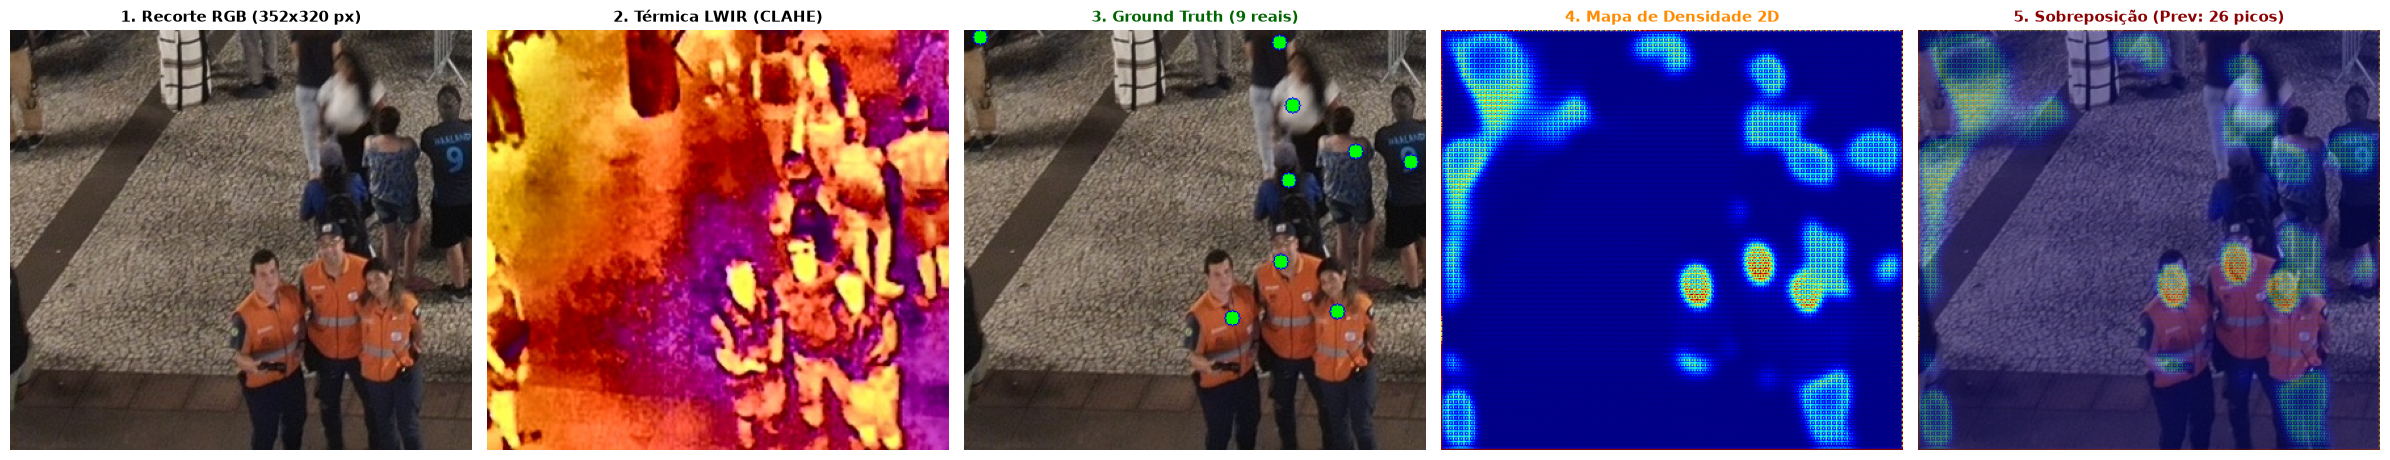

[✓] Painel de auditoria executivo salvo em: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc-small-images/output/02_contagem/painel_contagem_executivo.jpg


In [17]:
# Desenhar Ground Truth sobre a imagem RGB
vis_gt = img_rgb.copy()
for pt in gt_points:
    cv2.circle(vis_gt, (pt["x"], pt["y"]), 5, (0, 255, 0), -1)
    cv2.circle(vis_gt, (pt["x"], pt["y"]), 6, (0, 0, 255), 1)

# Redimensionar mapa de densidade para a resolução da imagem se necessário
if density_map.shape[:2] != (h, w):
    density_map_vis = cv2.resize(density_map, (w, h), interpolation=cv2.INTER_CUBIC)
    density_map_vis = np.clip(density_map_vis, 0, None)
else:
    density_map_vis = density_map

# Normalização robusta do mapa de calor (baseada no percentil 99 para evitar saturação por artefato de borda)
p99 = np.percentile(density_map_vis, 99.2)
vmax = max(p99, 0.002)
d_norm = np.clip(density_map_vis / vmax, 0.0, 1.0)
d_norm_uint8 = (d_norm * 255).astype(np.uint8)

heat_color = cv2.applyColorMap(d_norm_uint8, cv2.COLORMAP_JET)
heat_color = cv2.cvtColor(heat_color, cv2.COLOR_BGR2RGB)

# Alpha dinâmico para sobreposição limpa
overlay = cv2.addWeighted(img_rgb, 0.60, heat_color, 0.40, 0)

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

axes[0].imshow(img_rgb)
axes[0].set_title(f"1. Recorte RGB ({w}x{h} px)", fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(img_th)
axes[1].set_title("2. Térmica LWIR (CLAHE)", fontsize=11, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(vis_gt)
axes[2].set_title(f"3. Ground Truth ({real_count} reais)", fontsize=11, fontweight="bold", color="darkgreen")
axes[2].axis("off")

axes[3].imshow(heat_color)
axes[3].set_title("4. Mapa de Densidade 2D", fontsize=11, fontweight="bold", color="darkorange")
axes[3].axis("off")

axes[4].imshow(overlay)
axes[4].set_title(f"5. Sobreposição (Prev: {count_picos} picos)", fontsize=11, fontweight="bold", color="darkred")
axes[4].axis("off")

plt.tight_layout()
panel_path = OUTPUT_DIR / "painel_contagem_executivo.jpg"
plt.savefig(str(panel_path), dpi=150, bbox_inches="tight")
plt.show()

print(f"[✓] Painel de auditoria executivo salvo em: {panel_path}")

## 8. Métricas Avançadas de Validação do Modelo: MSE e NAE

**O que este código faz:**
Calcula e exibe duas métricas quantitativas fundamentais para validação de modelos neurais de contagem baseados em mapas de densidade:
1. **MSE (Mean Squared Error):**
   - **MSE Pixel-wise (Mapa 2D):** Mede a fidelidade espacial comparando pixel a pixel o mapa contínuo predito pela rede com o mapa de *Ground Truth* sintético (gerado convoluindo os pontos reais $(x, y)$ anotados por um auditor com uma distribuição gaussiana 2D, $\sigma = 4.0$).
   - **MSE de Contagem Escalar:** Avalia o desvio quadrático entre a contagem estimada ($\hat{C}$) e o total real ($C$).
2. **NAE (Normalized Absolute Error):**
   - Normaliza o erro absoluto pelo total de objetos reais ($\text{NAE} = \frac{|\hat{C} - C|}{C}$), permitindo comparar com justiça o desempenho do modelo em imagens com densidades muito variadas (de poucas pessoas a multidões compactas).

Além disso, constrói um painel gráfico com 3 visões: (1) Mapa de Densidade GT Sintético, (2) Mapa de Densidade Predito e (3) Mapa Residual de Erro Absoluto ($|\text{Predito} - \text{Real}|$).

**Por que esta lógica foi escolhida? (Decisão Técnica)**
- Em imagens com poucas pessoas, um erro de 5 pessoas em um grupo de 5 representa uma discrepância de 100% ($\text{NAE} = 1.0$), enquanto em 500 pessoas representaria apenas 1% ($\text{NAE} = 0.01$). O NAE elimina a distorção da escala e revela o impacto proporcional do erro.
- O MSE no mapa bidimensional penaliza severamente ativações espúrias distantes dos pedestres reais, atestando se a rede realmente concentrou a massa de probabilidade sobre as cabeças.

**Efeito prático no resultado:**
Tabela comparativa de validação no console exibindo o MSE do mapa 2D, MSE/RMSE de contagem e o NAE percentual (para a Integral e para os Picos Locais), acompanhado do gráfico `grafico_validacao_mse_nae.png`.

     MÉTRICAS AVANÇADAS DE VALIDAÇÃO DO MODELO: MSE E NAE
  • Pessoas Reais (Ground Truth):         9 pessoas
--------------------------------------------------------------------
  [1] MSE (Mean Squared Error):
      ├─ MSE Pixel-wise (Mapa 2D):        0.000001
      ├─ MSE Contagem (Integral Bruta):    1011.18 (RMSE: 31.80)
      └─ MSE Contagem (Picos Locais):      289.00 (RMSE: 17.00)
--------------------------------------------------------------------
  [2] NAE (Normalized Absolute Error):
      ├─ NAE - Integral Contínua Bruta:    3.5332 (353.3%)
      └─ NAE - Detecção por Picos Locais:  1.8889 (188.9%)


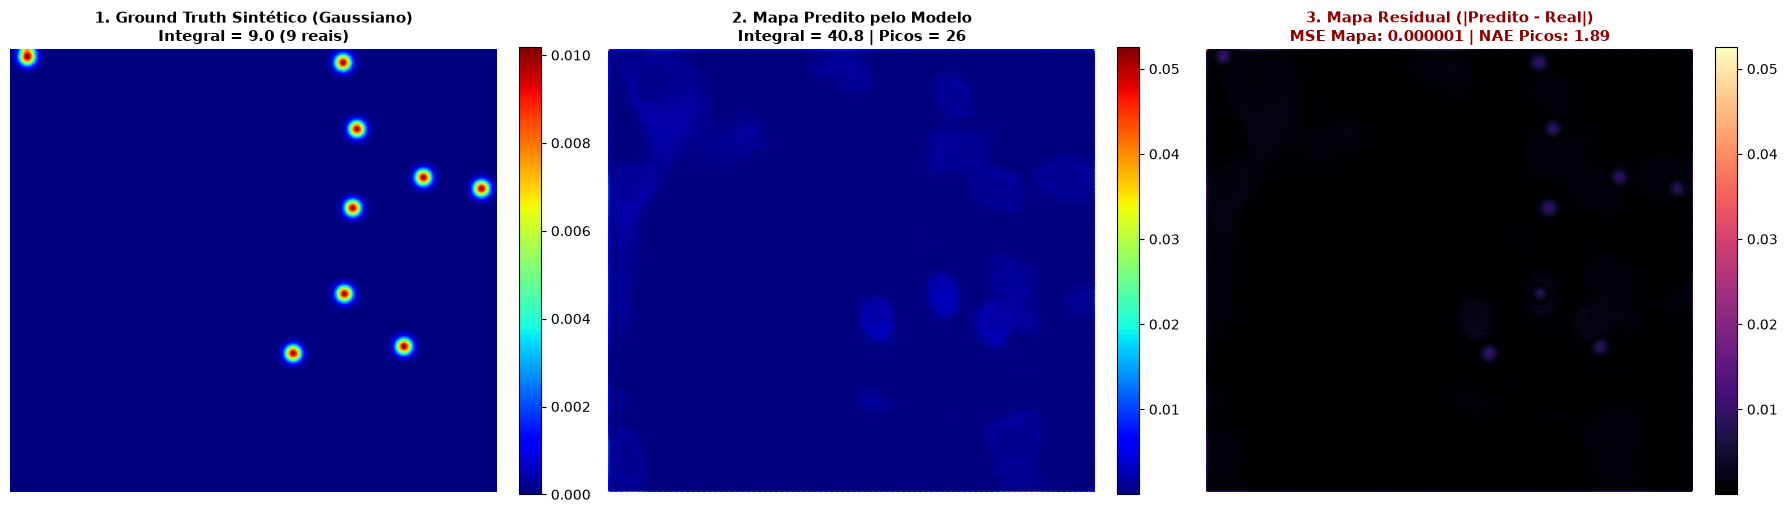

[✓] Painel de resíduos MSE/NAE salvo em: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc-small-images/output/02_contagem/grafico_validacao_mse_nae.png


In [18]:
from scipy.ndimage import gaussian_filter

# 1. Gerar o Mapa de Densidade Sintético de Ground Truth (Convolução Gaussiana 2D)
dmap_gt = np.zeros((h, w), dtype=np.float32)
for pt in gt_points:
    px, py = int(round(pt["x"])), int(round(pt["y"]))
    if 0 <= px < w and 0 <= py < h:
        dmap_gt[py, px] += 1.0

# Sigma calibrado para o diâmetro médio da cabeça no recorte (~4 pixels)
SIGMA_GT = 4.0
dmap_gt_gaussian = gaussian_filter(dmap_gt, sigma=SIGMA_GT)

# Assegurar que o mapa previsto esteja perfeitamente alinhado na resolução (w, h)
if density_map.shape[:2] != (h, w):
    dmap_pred_eval = cv2.resize(density_map, (w, h), interpolation=cv2.INTER_CUBIC)
    dmap_pred_eval = np.clip(dmap_pred_eval, 0, None)
else:
    dmap_pred_eval = density_map.copy()

# 2. Cálculo do MSE (Mean Squared Error)
# A. MSE no nível de Pixel (Fidelidade espacial da matriz 2D)
mse_mapa_pixels = float(np.mean((dmap_pred_eval - dmap_gt_gaussian) ** 2))

# B. MSE e RMSE na Contagem Escalar (Integral e Picos)
mse_contagem_integral = float((count_integral - real_count) ** 2)
mse_contagem_picos = float((count_picos - real_count) ** 2)
rmse_contagem_integral = float(np.sqrt(mse_contagem_integral))
rmse_contagem_picos = float(np.sqrt(mse_contagem_picos))

# 3. Cálculo do NAE (Normalized Absolute Error)
# Proteção contra divisão por zero para controle negativo (0 pessoas reais)
denominador_nae = max(real_count, 1)
nae_integral = float(abs(count_integral - real_count) / denominador_nae)
nae_picos = float(abs(count_picos - real_count) / denominador_nae)

# 4. Mapa Residual de Erro Espacial (|Predito - Real|)
mapa_residual = np.abs(dmap_pred_eval - dmap_gt_gaussian)

# Exibição no console
print("=" * 68)
print("     MÉTRICAS AVANÇADAS DE VALIDAÇÃO DO MODELO: MSE E NAE")
print("=" * 68)
print(f"  • Pessoas Reais (Ground Truth):         {real_count} pessoas")
print("-" * 68)
print("  [1] MSE (Mean Squared Error):")
print(f"      ├─ MSE Pixel-wise (Mapa 2D):        {mse_mapa_pixels:.6f}")
print(f"      ├─ MSE Contagem (Integral Bruta):    {mse_contagem_integral:.2f} (RMSE: {rmse_contagem_integral:.2f})")
print(f"      └─ MSE Contagem (Picos Locais):      {mse_contagem_picos:.2f} (RMSE: {rmse_contagem_picos:.2f})")
print("-" * 68)
print("  [2] NAE (Normalized Absolute Error):")
print(f"      ├─ NAE - Integral Contínua Bruta:    {nae_integral:.4f} ({nae_integral * 100:.1f}%)")
print(f"      └─ NAE - Detecção por Picos Locais:  {nae_picos:.4f} ({nae_picos * 100:.1f}%)")
print("=" * 68)

# 5. Painel Gráfico Comparativo: Real vs Predito vs Resíduo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(dmap_gt_gaussian, cmap="jet")
axes[0].set_title(f"1. Ground Truth Sintético (Gaussiano)\nIntegral = {np.sum(dmap_gt_gaussian):.1f} ({real_count} reais)", fontsize=11, fontweight="bold")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(dmap_pred_eval, cmap="jet")
axes[1].set_title(f"2. Mapa Predito pelo Modelo\nIntegral = {count_integral:.1f} | Picos = {count_picos}", fontsize=11, fontweight="bold")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(mapa_residual, cmap="magma")
axes[2].set_title(f"3. Mapa Residual (|Predito - Real|)\nMSE Mapa: {mse_mapa_pixels:.6f} | NAE Picos: {nae_picos:.2f}", fontsize=11, fontweight="bold", color="darkred")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
metrics_plot_path = OUTPUT_DIR / "grafico_validacao_mse_nae.png"
plt.savefig(str(metrics_plot_path), dpi=150, bbox_inches="tight")
plt.show()

print(f"[✓] Painel de resíduos MSE/NAE salvo em: {metrics_plot_path}")

## 9. Exportação de Entregáveis e Telemetria em JSON

**O que este código faz:**
Exporta a matriz de densidade no formato NumPy binário (`density_map.npy`), salva as imagens de auditoria e grava o relatório estruturado `telemetria_contagem.json` contendo tempos de execução, contagens, erros e as métricas de validação calculadas (**MSE** e **NAE**).

**Por que esta lógica foi escolhida?**
A persistência estruturada em JSON permite integrar os resultados com sistemas de dashboards, relatórios automatizados em PDF/Word e com o **Notebook 03** para consolidação de estudos em lote.

**Efeito prático no resultado:**
Todos os artefatos ficam disponíveis em disco prontos para auditoria e consumo downstream.

In [9]:
np.save(str(OUTPUT_DIR / "density_map.npy"), density_map)
cv2.imwrite(str(OUTPUT_DIR / "sobreposicao_mapa_calor.jpg"), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

telemetria = {
    "modelo": MODELO_NOME,
    "arquitetura": ARQUITETURA_NOME,
    "amostra_avaliada": meta.get("nome_amostra"),
    "dimensoes": [w, h],
    "latencia_ms": round(latency_ms, 2),
    "fps": round(1000.0 / max(latency_ms, 0.001), 1),
    "metricas_contagem": {
        "ground_truth_real": real_count,
        "contagem_integral_continua": round(count_integral, 2),
        "contagem_picos_locais": count_picos,
        "token_coarse_count": round(token_count, 2),
        "erro_absoluto_integral": round(abs(erro_integral), 2),
        "erro_absoluto_picos": abs(erro_picos)
    },
    "metricas_validacao": {
        "mse_pixelwise_mapa_2d": round(mse_mapa_pixels, 6),
        "mse_contagem_integral": round(mse_contagem_integral, 2),
        "rmse_contagem_integral": round(rmse_contagem_integral, 2),
        "mse_contagem_picos": round(mse_contagem_picos, 2),
        "rmse_contagem_picos": round(rmse_contagem_picos, 2),
        "nae_integral": round(nae_integral, 4),
        "nae_picos": round(nae_picos, 4),
        "nae_picos_percentual": f"{nae_picos * 100:.1f}%"
    },
    "arquivos_saida": {
        "matriz_npy": "output/02_contagem/density_map.npy",
        "painel_auditoria": "output/02_contagem/painel_contagem_executivo.jpg",
        "sobreposicao": "output/02_contagem/sobreposicao_mapa_calor.jpg",
        "grafico_validacao_mse_nae": "output/02_contagem/grafico_validacao_mse_nae.png"
    }
}

tel_path = OUTPUT_DIR / "telemetria_contagem.json"
with open(tel_path, "w", encoding="utf-8") as f:
    json.dump(telemetria, f, indent=2, ensure_ascii=False)

print("=" * 65)
print("     ESTÁGIO 2 CONCLUÍDO: ENTREGÁVEIS E TELEMETRIA GERADOS")
print("=" * 65)
print(f"1. Matriz Numérica 2D:     {OUTPUT_DIR / 'density_map.npy'}")
print(f"2. Painel Executivo:       {panel_path}")
print(f"3. Gráfico Validação MSE:  {metrics_plot_path}")
print(f"4. Telemetria Estruturada: {tel_path}")
print("=" * 65)

     ESTÁGIO 2 CONCLUÍDO: ENTREGÁVEIS E TELEMETRIA GERADOS
1. Matriz Numérica 2D:     /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc-small-images/output/02_contagem/density_map.npy
2. Painel Executivo:       /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc-small-images/output/02_contagem/painel_contagem_executivo.jpg
3. Gráfico Validação MSE:  /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc-small-images/output/02_contagem/grafico_validacao_mse_nae.png
4. Telemetria Estruturada: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc-small-images/output/02_contagem/telemetria_contagem.json


## 10. Apresentação: Resultado da Contagem em Texto

**O que este código faz:**
Exibe um resumo executivo direto e em destaque dos resultados obtidos no console (contagem discreta estimada, pessoas reais no Ground Truth, erro absoluto, métricas de validação **MSE** e **NAE** e tempo de inferência), além de renderizar um card visual HTML de alto impacto para apresentação executiva.

**Por que esta lógica foi escolhida?**
Apresentações para gestores e relatórios de campo demandam clareza e síntese imediata sem a necessidade de inspecionar arrays numéricos ou arquivos JSON. O bloco textual formatado em destaque e o card HTML oferecem uma leitura limpa, padronizada e autoexplicativa.

**Efeito prático no resultado:**
Um bloco de texto formatado com moldura no console com o número final de pessoas estimadas, métricas quantitativas de MSE/NAE e um card visual estilizado com as métricas do modelo.

In [10]:
# ==============================================================================
# 10. APRESENTAÇÃO: RESULTADO DA CONTAGEM EM TEXTO
# ==============================================================================
import json
from pathlib import Path
from IPython.display import display, HTML

# Recuperação das variáveis (da memória ou do arquivo de telemetria)
try:
    _count_picos = count_picos
    _count_integral = count_integral
    _real = real_count
    _erro_picos = erro_picos
    _time_ms = latency_ms
    _fps = fps
    _dev = str(device)
    _amostra = meta.get("nome_amostra", "Recorte Baixa Densidade")
    _mse_mapa = mse_mapa_pixels
    _nae_picos = nae_picos
except NameError:
    _tel = Path("output/02_contagem/telemetria_contagem.json")
    with open(_tel, "r", encoding="utf-8") as _f:
        _d = json.load(_f)
    _count_picos = _d["metricas_contagem"]["contagem_picos_locais"]
    _count_integral = _d["metricas_contagem"]["contagem_integral_continua"]
    _real = _d["metricas_contagem"]["ground_truth_real"]
    _erro_picos = _d["metricas_contagem"]["erro_absoluto_picos"]
    _time_ms = _d["latencia_ms"]
    _fps = _d["fps"]
    _dev = "GPU/CPU"
    _amostra = _d.get("amostra_avaliada", "Recorte Baixa Densidade")
    _mv = _d.get("metricas_validacao", {})
    _mse_mapa = _mv.get("mse_pixelwise_mapa_2d", 0.0)
    _nae_picos = _mv.get("nae_picos", 0.0)

# 1. Exibição textual destacada para leitura direta e apresentação
print("=" * 68)
print(f"       RESULTADO DA CONTAGEM EM RECORTES ({MODELO_NOME.upper()})")
print("=" * 68)
print(f"  >>> TOTAL ESTIMADO (PICOS LOCAIS): {_count_picos} PESSOAS <<<")
print(f"  >>> TOTAL REAL (GROUND TRUTH):     {_real} PESSOAS <<<")
print("-" * 68)
print(f"  • Cenário Avaliado:              {_amostra}")
print(f"  • Erro Absoluto da Contagem:     {abs(_erro_picos)} pessoa(s)")
print(f"  • Integral Contínua (Densidade): {_count_integral:.2f}")
print(f"  • MSE do Mapa de Densidade 2D:   {_mse_mapa:.6f}")
print(f"  • NAE (Erro Normalizado Picos):  {_nae_picos:.4f} ({_nae_picos * 100:.1f}%)")
print(f"  • Tempo de Inferência:           {_time_ms:.1f} ms ({_fps:.1f} FPS)")
print(f"  • Dispositivo de Processamento:  {_dev}")
print("=" * 68)

# 2. Card visual executivo
_card_color = "#38bdf8" if "def" in MODELO_NOME.lower() else "#a855f7"
_badge_color = "#7dd3fc" if "def" in MODELO_NOME.lower() else "#d8b4fe"

card_html = f"""<div style="font-family: 'Segoe UI', -apple-system, BlinkMacSystemFont, Roboto, sans-serif; max-width: 620px; margin: 15px 0; padding: 20px 26px; background: #0f172a; border-radius: 12px; border-left: 6px solid {_card_color}; box-shadow: 0 4px 15px rgba(0,0,0,0.25); color: #f8fafc;">
    <div style="text-transform: uppercase; letter-spacing: 1.2px; font-size: 12px; font-weight: 700; color: {_badge_color}; margin-bottom: 6px;">Relatório Executivo • {MODELO_NOME}</div>
    <div style="font-size: 32px; font-weight: 800; color: #4ade80; margin: 6px 0 10px 0; line-height: 1.2;">👥 {_count_picos} Pessoas Estimadas <span style="font-size: 18px; color: #94a3b8; font-weight: 500;">(Real: {_real})</span></div>
    <div style="font-size: 14px; color: #cbd5e1; border-top: 1px solid rgba(255,255,255,0.12); padding-top: 10px; line-height: 1.6;">
        <b>Cenário:</b> {_amostra}<br>
        <b>Acurácia:</b> Erro de {abs(_erro_picos)} pessoa(s) | <b>NAE Picos:</b> {_nae_picos * 100:.1f}%<br>
        <b>MSE Mapa 2D:</b> {_mse_mapa:.6f} | <b>Integral Bruta:</b> {_count_integral:.2f}<br>
        <b>Tempo de Inferência:</b> {_time_ms:.1f} ms ({_fps:.1f} FPS) | <b>Dispositivo:</b> {_dev}
    </div>
</div>"""
display(HTML(card_html))

       RESULTADO DA CONTAGEM EM RECORTES (DEF-RGBTCC-SMALL-IMAGES)
  >>> TOTAL ESTIMADO (PICOS LOCAIS): 26 PESSOAS <<<
  >>> TOTAL REAL (GROUND TRUTH):     9 PESSOAS <<<
--------------------------------------------------------------------
  • Cenário Avaliado:              Calçada de Pedestres no Solo (Fiscais)
  • Erro Absoluto da Contagem:     17 pessoa(s)
  • Integral Contínua (Densidade): 40.80
  • MSE do Mapa de Densidade 2D:   0.000001
  • NAE (Erro Normalizado Picos):  1.8889 (188.9%)
  • Tempo de Inferência:           244.6 ms (4.1 FPS)
  • Dispositivo de Processamento:  GPU/CPU
